In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('train.csv')

In [9]:
df.columns.to_list()

['Type',
 'Name',
 'Age',
 'Breed1',
 'Breed2',
 'Gender',
 'Color1',
 'Color2',
 'Color3',
 'MaturitySize',
 'FurLength',
 'Vaccinated',
 'Dewormed',
 'Sterilized',
 'Health',
 'Quantity',
 'Fee',
 'State',
 'RescuerID',
 'VideoAmt',
 'Description',
 'PetID',
 'PhotoAmt',
 'AdoptionSpeed']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

In [ ]:
# Convert Breed1, Breed2, Color1, Color2, Color3, and State to string
df['Breed1'] = df['Breed1'].astype(str)
df['Breed2'] = df['Breed2'].astype(str)
df['Color1'] = df['Color1'].astype(str)
df['Color2'] = df['Color2'].astype(str)
df['Color3'] = df['Color3'].astype(str)
df['State'] = df['State'].astype(str)

print("Columns converted to string:")
print(df[['Breed1', 'Breed2', 'Color1', 'Color2', 'Color3', 'State']].dtypes)
print("\nFirst few rows:")
print(df[['Breed1', 'Breed2', 'Color1', 'Color2', 'Color3', 'State']].head())

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Preparar datos para predecir AdoptionSpeed (multiclase: 0, 1, 2, 3, 4)
y_adoption = df['AdoptionSpeed']

# Dividir en entrenamiento y prueba
X_train_speed, X_test_speed, y_train_speed, y_test_speed = train_test_split(
    X, y_adoption, test_size=0.2, random_state=42
)

# Entrenar modelo multiclase
model_adoption_speed = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model_adoption_speed.fit(X_train_speed, y_train_speed)

# Predicciones
y_pred_adoption = model_adoption_speed.predict(X_test_speed)
y_pred_adoption_proba = model_adoption_speed.predict_proba(X_test_speed)

# Evaluación

print("Exactitud:", accuracy_score(y_test_speed, y_pred_adoption))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test_speed, y_pred_adoption))
print("\nReporte de Clasificación:")
print(classification_report(y_test_speed, y_pred_adoption, 
                          target_names=['Muy Rápido (0)', 'Rápido (1)', 'Normal (2)', 'Lento (3)', 'Muy Lento (4)']))

# Importancia de características
feature_importance_adoption = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_adoption_speed.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportancia de Variables:")
print(feature_importance_adoption.head(15))

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_adoption['Feature'].head(15), feature_importance_adoption['Importance'].head(15))
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Importancia de Variables para Predicción de Adoption Speed')
plt.tight_layout()
plt.show()

NameError: name 'train_test_split' is not defined

In [13]:
# Analizar casos donde Breed1 = Breed2, distintos y vs 0
breed_analysis = pd.DataFrame({
    'Breed1_equals_Breed2': [(df['Breed1'] == df['Breed2']).sum()],
    'Breed1_not_equals_Breed2': [(df['Breed1'] != df['Breed2']).sum()],
    'Breed1_equals_0': [(df['Breed1'] == 0).sum()],
    'Breed2_equals_0': [(df['Breed2'] == 0).sum()],
    'Both_Breed1_and_Breed2_equal_0': [((df['Breed1'] == 0) & (df['Breed2'] == 0)).sum()],
    'Only_Breed1_equals_0': [((df['Breed1'] == 0) & (df['Breed2'] != 0)).sum()],
    'Only_Breed2_equals_0': [((df['Breed1'] != 0) & (df['Breed2'] == 0)).sum()]
})

print("Análisis de Razas:")
print(breed_analysis.T)
print(f"\nTotal de registros: {len(df)}")

Análisis de Razas:
                                    0
Breed1_equals_Breed2             1510
Breed1_not_equals_Breed2        13483
Breed1_equals_0                     5
Breed2_equals_0                 10762
Both_Breed1_and_Breed2_equal_0      0
Only_Breed1_equals_0                5
Only_Breed2_equals_0            10762

Total de registros: 14993


In [15]:
# Flag for mixed breed (both Breed1 and Breed2 are not 0)
df['Has_Both_Breeds'] = ((df['Breed1'] != 0) & (df['Breed2'] != 0)).astype(int)

# Add to X for model training
X['Has_Both_Breeds'] = df['Has_Both_Breeds']

print(df[['Breed1', 'Breed2', 'Has_Both_Breeds']].head(10))

   Breed1  Breed2  Has_Both_Breeds
0     299       0                0
1     265       0                0
2     307       0                0
3     307       0                0
4     307       0                0
5     266       0                0
6     264     264                1
7     307       0                0
8     265       0                0
9     265       0                0


In [19]:
# Create ratios between variables
df['Age_Fee_Ratio'] = df['Age'] / (df['Fee'] + 1)  # +1 to avoid division by zero
df['Gender_Fee_Ratio'] = df['Gender'] / (df['Fee'] + 1)


# View the new columns
print(df[['Age', 'Fee','Gender_Fee_Ratio']].head())

   Age  Fee  Gender_Fee_Ratio
0    3  100          0.009901
1    1    0          1.000000
2    1    0          1.000000
3    4  150          0.013245
4    1    0          1.000000


In [20]:
# Flag for high-quality listings (good documentation)
df['High_Quality_Listing'] = ((df['PhotoAmt'] >= df['PhotoAmt'].quantile(0.75)) & 
                               (df['Is_Described'] == 1)).astype(int)

# Flag for premium pets (vaccinated, dewormed, and sterilized)
df['Premium_Pet'] = ((df['Vaccinated'] >= 2) & 
                     (df['Dewormed'] >= 2) & 
                     (df['Sterilized'] >= 2)).astype(int)

# Flag for healthy pets
df['Healthy'] = (df['Total_Health_Score'] >= 3).astype(int)

# Flag for affordable pets (below median fee)
df['Affordable'] = (df['Fee'] <= df['Fee'].quantile(0.5)).astype(int)

# Flag for young pets (age below median)
df['Young_Pet'] = (df['Age'] <= df['Age'].quantile(0.5)).astype(int)

# Flag for mixed breed (has both Breed1 and Breed2)
df['Mixed_Breed'] = ((df['Breed1'] != 0) & (df['Breed2'] != 0)).astype(int)

# Flag for multiple colors
df['Multicolor'] = (df['Total_Colors'] >= 2).astype(int)

# Add flags to X for model training
X['High_Quality_Listing'] = df['High_Quality_Listing']
X['Premium_Pet'] = df['Premium_Pet']
X['Healthy'] = df['Healthy']
X['Affordable'] = df['Affordable']
X['Young_Pet'] = df['Young_Pet']
X['Mixed_Breed'] = df['Mixed_Breed']
X['Multicolor'] = df['Multicolor']

print("New flags created successfully!")
print(df[['High_Quality_Listing', 'Premium_Pet', 'Healthy', 'Affordable', 'Young_Pet', 'Mixed_Breed', 'Multicolor']].head(10))

KeyError: 'Is_Described'

In [21]:
# Create a reputation/quality score for pets
df['Reputation_Score'] = (
    # Health component (0-30 points)
    (df['Total_Health_Score'] / df['Total_Health_Score'].max() * 30) +
    
    # Care component - vaccinated, dewormed, sterilized (0-20 points)
    ((df['Vaccinated'] + df['Dewormed'] + df['Sterilized']) / 9 * 20) +
    
    # Breed quality - common breeds score higher (0-15 points)
    (15 - (df['Breed1'] / df['Breed1'].max() * 15)) +
    
    # Documentation quality (0-15 points)
    (df['PhotoAmt'] / df['PhotoAmt'].max() * 10 + 
     df['Has_Video'] * 5) +
    
    # Maturity and size (0-10 points)
    (df['MaturitySize'] / df['MaturitySize'].max() * 10) +
    
    # Reasonable fee (0-10 points) - lower fees indicate better reputation
    (10 - (df['Fee'] / df['Fee'].max() * 10).clip(lower=0))
)

# Normalize to 0-100 scale
df['Reputation_Score'] = (df['Reputation_Score'] / df['Reputation_Score'].max() * 100)

print("Reputation Score Statistics:")
print(df['Reputation_Score'].describe())
print("\nCorrelation with AdoptionSpeed:")
print(df['Reputation_Score'].corr(df['AdoptionSpeed']))

# Also add to X for model training
X['Reputation_Score'] = df['Reputation_Score']

KeyError: 'Total_Health_Score'

               Feature  Importance
19     Will_Be_Adopted    0.304994
23  Age_PhotoAmt_Ratio    0.076963
18            PhotoAmt    0.062311
6               Color2    0.050633
5               Color1    0.049121
2               Breed1    0.047297
20       Age_Fee_Ratio    0.046915
1                  Age    0.043493
16               State    0.039727
22    Gender_Fee_Ratio    0.027469
9            FurLength    0.027065
3               Breed2    0.026295
8         MaturitySize    0.025300
7               Color3    0.024369
14            Quantity    0.024044
11            Dewormed    0.022125
10          Vaccinated    0.019673
4               Gender    0.018869
12          Sterilized    0.018755
15                 Fee    0.012338
21     Has_Both_Breeds    0.012104
17            VideoAmt    0.007387
0                 Type    0.007248
13              Health    0.005506


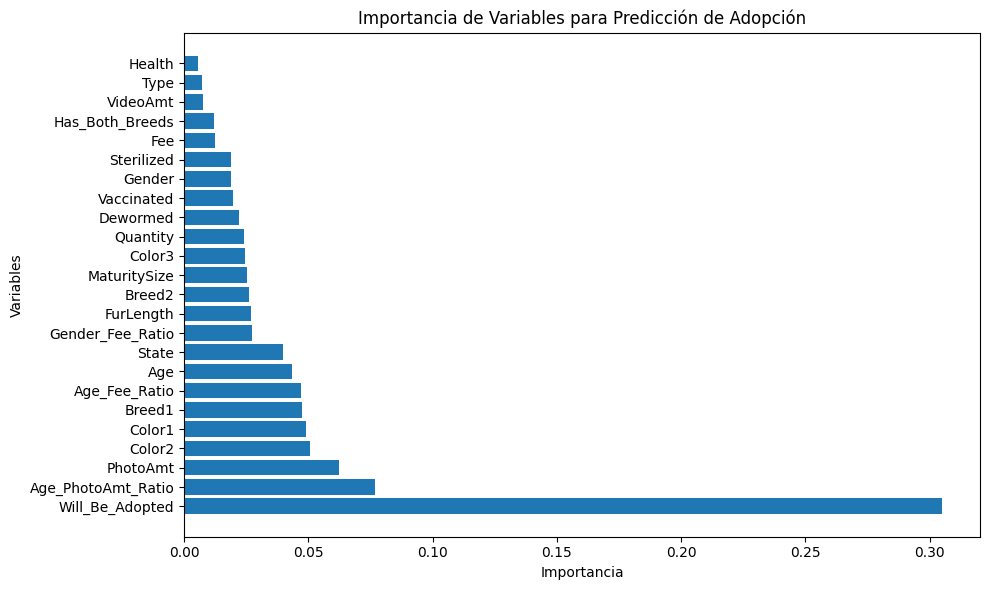

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Preparar los datos (excluir columnas no numéricas y la variable objetivo)
X = df.drop(['AdoptionSpeed', 'Name', 'Description', 'PetID', 'RescuerID'], axis=1)
y = df['AdoptionSpeed']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Obtener importancia de variables
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Importancia de Variables para Predicción de Adopción')
plt.tight_layout()
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Calcular matriz de correlación
correlation_matrix = X.corr()

# Identificar variables altamente correlacionadas (> 0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print("Variables altamente correlacionadas (> 0.9):")
for var1, var2, corr in high_corr_pairs:
    print(f"{var1} - {var2}: {corr:.3f}")

# Calcular VIF para detectar multicolinealidad
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF (Variance Inflation Factor):")
print(vif_data)

# Variables con VIF > 10 indican multicolinealidad problemática
problematic_vars = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nVariables con VIF > 10 (problemáticas): {problematic_vars}")

# Eliminar variables altamente correlacionadas y con alto VIF
vars_to_drop = set()

# Agregar variables correlacionadas (mantener la de mayor importancia)
for var1, var2, corr in high_corr_pairs:
    imp1 = feature_importance[feature_importance['Feature'] == var1]['Importance'].values
    imp2 = feature_importance[feature_importance['Feature'] == var2]['Importance'].values
    if len(imp1) > 0 and len(imp2) > 0:
        if imp1[0] < imp2[0]:
            vars_to_drop.add(var1)
        else:
            vars_to_drop.add(var2)

# Agregar variables con VIF alto (mantener las de mayor importancia)
for var in problematic_vars:
    vars_to_drop.add(var)

print(f"\nVariables a eliminar: {vars_to_drop}")

# Crear nuevo dataset sin las variables problemáticas
X_filtered = X.drop(columns=list(vars_to_drop))
print(f"\nDimensiones originales X: {X.shape}")
print(f"Dimensiones X filtrado: {X_filtered.shape}")

Variables altamente correlacionadas (> 0.9):
Breed2 - Has_Both_Breeds: 0.959

VIF (Variance Inflation Factor):
               Feature         VIF
16               State  112.516531
13              Health   28.728615
2               Breed1   25.100667
4               Gender   22.790075
10          Vaccinated   17.907174
21     Has_Both_Breeds   17.798703
3               Breed2   17.226470
12          Sterilized   17.075771
22    Gender_Fee_Ratio   13.399874
8         MaturitySize   13.353334
11            Dewormed   13.252139
1                  Age   12.809175
0                 Type   11.758679
20       Age_Fee_Ratio    8.945337
9            FurLength    7.629228
23  Age_PhotoAmt_Ratio    4.619698
19     Will_Be_Adopted    3.816812
5               Color1    3.067447
14            Quantity    3.045264
18            PhotoAmt    2.717664
6               Color2    2.601188
15                 Fee    1.869848
7               Color3    1.762968
17            VideoAmt    1.085237

Variables con

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Convertir AdoptionSpeed a binario: 0 = No adoptado rápido, 1 = Adoptado rápido
# Consideramos adoptado rápido si AdoptionSpeed < 2 (0 o 1)
y_binary = (y < 2).astype(int)
y_train_binary = (y_train < 2).astype(int)
y_test_binary = (y_test < 2).astype(int)

# Entrenar modelo con clases binarias
model_binary = RandomForestClassifier(n_estimators=100, random_state=42)
model_binary.fit(X_train, y_train_binary)

# Predicciones
y_pred = model_binary.predict(X_test)

# Evaluación
print("Exactitud:", accuracy_score(y_test_binary, y_pred))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test_binary, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test_binary, y_pred, target_names=['No Adoptado Rápido', 'Adoptado Rápido']))

# Probabilidades de adopción
y_pred_proba = model_binary.predict_proba(X_test)
print("\nProbabilidades de adopción (primeras 5):")
print(y_pred_proba[:5])

Exactitud: 0.7635878626208736

Matriz de Confusión:
[[2124  156]
 [ 553  166]]

Reporte de Clasificación:
                    precision    recall  f1-score   support

No Adoptado Rápido       0.79      0.93      0.86      2280
   Adoptado Rápido       0.52      0.23      0.32       719

          accuracy                           0.76      2999
         macro avg       0.65      0.58      0.59      2999
      weighted avg       0.73      0.76      0.73      2999


Probabilidades de adopción (primeras 5):
[[1.     0.    ]
 [0.6555 0.3445]
 [0.98   0.02  ]
 [0.59   0.41  ]
 [0.53   0.47  ]]


Mejores parámetros: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200, 'random_state': 42}
Mejor score CV: 0.4068

=== EVALUACIÓN DEL MODELO DE VELOCIDAD DE ADOPCIÓN ===
Exactitud: 0.4308

Matriz de Confusión:
[[  4  32  28   5  23]
 [  0 216 240  48 123]
 [  0 156 345 100 205]
 [  0 106 168 153 214]
 [  0  60 151  48 574]]

Reporte de Clasificación:
                precision    recall  f1-score   support

Muy Rápido (0)       1.00      0.04      0.08        92
    Rápido (1)       0.38      0.34      0.36       627
    Normal (2)       0.37      0.43      0.40       806
     Lento (3)       0.43      0.24      0.31       641
 Muy Lento (4)       0.50      0.69      0.58       833

      accuracy                           0.43      2999
     macro avg       0.54      0.35      0.35      2999
  weighted avg       0.44      0.43      0.41      2999


Top 15 Variables más importantes:
         Feature  Importance
1            Age    0.142629
18      Phot

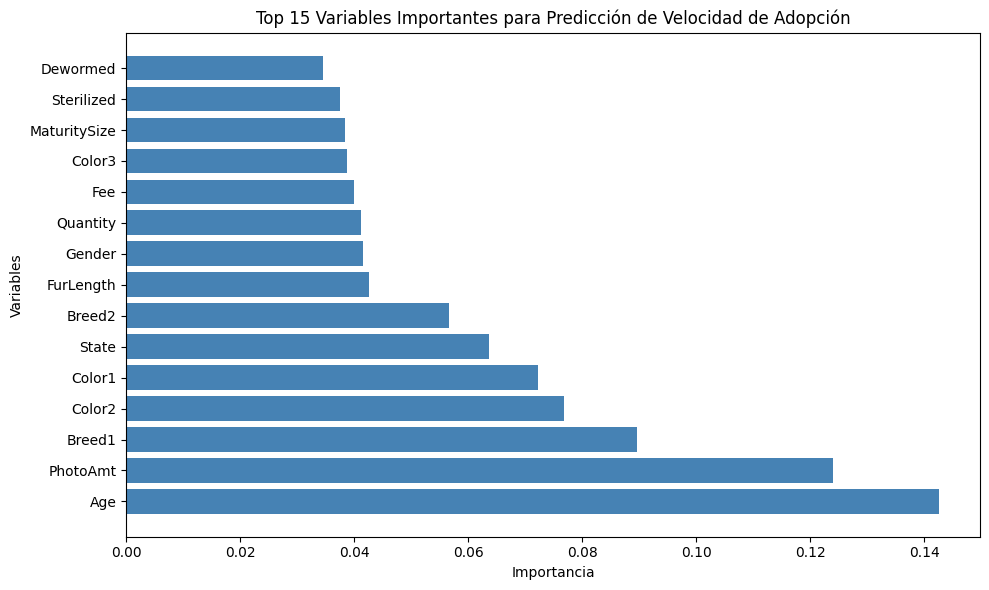

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Entrenar un modelo mejorado para predecir velocidad de adopción con hiperparámetros optimizados

# Usar X_train_speed y X_test_speed (sin features problemáticas)
# Encontrar hiperparámetros óptimos
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'random_state': [42]
}

rf_adoption_speed = RandomForestClassifier(n_jobs=-1, random_state=42)
grid_search = GridSearchCV(rf_adoption_speed, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_speed, y_train_speed)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score CV: {grid_search.best_score_:.4f}")

# Entrenar modelo final con mejores parámetros
best_model_adoption_speed = grid_search.best_estimator_

# Predicciones
y_pred_adoption_final = best_model_adoption_speed.predict(X_test_speed)
y_pred_adoption_proba_final = best_model_adoption_speed.predict_proba(X_test_speed)

# Evaluación
print("\n=== EVALUACIÓN DEL MODELO DE VELOCIDAD DE ADOPCIÓN ===")
print(f"Exactitud: {accuracy_score(y_test_speed, y_pred_adoption_final):.4f}")
print(f"\nMatriz de Confusión:\n{confusion_matrix(y_test_speed, y_pred_adoption_final)}")
print(f"\nReporte de Clasificación:\n{classification_report(y_test_speed, y_pred_adoption_final, target_names=['Muy Rápido (0)', 'Rápido (1)', 'Normal (2)', 'Lento (3)', 'Muy Lento (4)'])}")

# Importancia de características
feature_importance_final = pd.DataFrame({
    'Feature': X_train_speed.columns,
    'Importance': best_model_adoption_speed.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Variables más importantes:")
print(feature_importance_final.head(15))

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_final['Feature'].head(15), feature_importance_final['Importance'].head(15), color='steelblue')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Top 15 Variables Importantes para Predicción de Velocidad de Adopción')
plt.tight_layout()
plt.show()

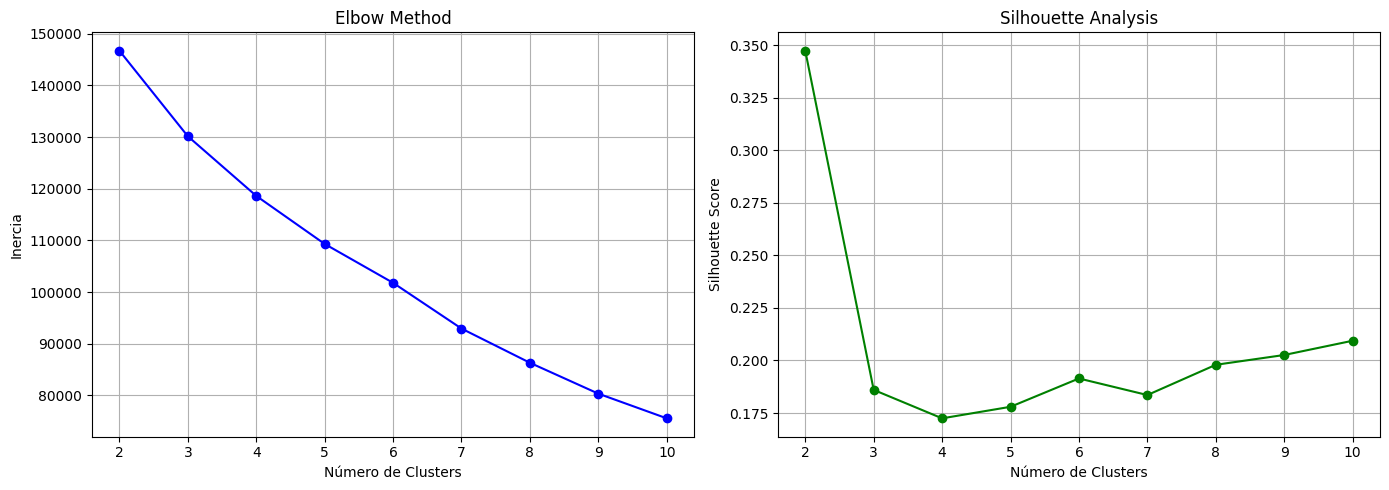

Distribución de clusters:
Cluster
0    4249
1    5683
2    4208
3     853
Name: count, dtype: int64

Características por cluster:
           Color1    Color2    Color3  FurLength  Quantity        Fee  \
Cluster                                                                 
0        2.381266  6.560838  0.000000   1.438456  1.323606  21.675453   
1        2.648425  0.595636  0.045047   1.445187  1.225761  25.125110   
2        1.435361  3.526378  6.379515   1.466017  2.391160  18.417538   
3        2.682298  2.601407  1.308324   1.767878  1.146542   7.461899   

         VideoAmt  PhotoAmt  Will_Be_Adopted  Age_Fee_Ratio  
Cluster                                                      
0        0.065192  4.006825         0.744175       5.491480  
1        0.042231  3.471934         0.715995       5.337740  
2        0.074144  4.658032         0.722433       4.973967  
3        0.025791  2.290739         0.615475      63.006428  


In [26]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# Seleccionar features numéricos para clustering (excluir variables problemáticas)
features_for_clustering = X_filtered.columns.tolist()

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# Determinar número óptimo de clusters usando elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Graficar elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Número de Clusters')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Elbow Method')
axes[0].grid()

axes[1].plot(K_range, silhouette_scores, 'go-')
axes[1].set_xlabel('Número de Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].grid()

plt.tight_layout()
plt.show()

# Entrenar modelo con k=4 (ajusta según los gráficos)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Distribución de clusters:\n{df['Cluster'].value_counts().sort_index()}")
print(f"\nCaracterísticas por cluster:")
print(df.groupby('Cluster')[features_for_clustering[:10]].mean())

In [27]:
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Modelo 1: XGBoost
params_xgb = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42
}

dtrain = xgb.DMatrix(X_train, label=y_train_binary)
dtest = xgb.DMatrix(X_test, label=y_test_binary)

model_xgb = xgb.train(
    params_xgb,
    dtrain,
    num_boost_round=100,
    evals=[(dtest, 'test')],
    verbose_eval=False
)

y_pred_xgb = model_xgb.predict(dtest)
y_pred_xgb_binary = (y_pred_xgb > 0.5).astype(int)

# Modelo 2: Gradient Boosting
model_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model_gb.fit(X_train, y_train_binary)

y_pred_gb = model_gb.predict(X_test)
y_pred_gb_proba = model_gb.predict_proba(X_test)[:, 1]

# Modelo 3: LightGBM (ya entrenado, usar el existente)
# y_pred_lgb_binary ya existe

# Comparar modelos
results = pd.DataFrame({
    'Modelo': ['XGBoost', 'Gradient Boosting', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test_binary, y_pred_xgb_binary),
        accuracy_score(y_test_binary, y_pred_gb),
        accuracy_score(y_test_binary, y_pred_lgb_binary)
    ],
    'Precision': [
        precision_score(y_test_binary, y_pred_xgb_binary),
        precision_score(y_test_binary, y_pred_gb),
        precision_score(y_test_binary, y_pred_lgb_binary)
    ],
    'Recall': [
        recall_score(y_test_binary, y_pred_xgb_binary),
        recall_score(y_test_binary, y_pred_gb),
        recall_score(y_test_binary, y_pred_lgb_binary)
    ],
    'F1-Score': [
        f1_score(y_test_binary, y_pred_xgb_binary),
        f1_score(y_test_binary, y_pred_gb),
        f1_score(y_test_binary, y_pred_lgb_binary)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_binary, y_pred_xgb),
        roc_auc_score(y_test_binary, y_pred_gb_proba),
        roc_auc_score(y_test_binary, y_pred_lgb)
    ]
})

print("Comparación de Modelos:")
print(results)
print("\nMejor modelo por métrica:")
print(results.set_index('Modelo').idxmax())

Comparación de Modelos:
              Modelo  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0            XGBoost  0.770924   0.612676  0.121001  0.202091  0.789390
1  Gradient Boosting  0.769923   0.588957  0.133519  0.217687  0.791508
2           LightGBM  0.766922   0.553763  0.143255  0.227624  0.791013

Mejor modelo por métrica:
Accuracy               XGBoost
Precision              XGBoost
Recall                LightGBM
F1-Score              LightGBM
ROC-AUC      Gradient Boosting
dtype: object
